# Function 1
This function has 2 dimensions.

In [104]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
import statistics
from matplotlib.widgets import Slider
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets
import time



### Data preparation

Here we prepare the initial data provided

In [2]:
input = np.load('./../../../data/initial_data/function_1/initial_inputs.npy')
output = np.load('./../../../data/initial_data/function_1/initial_outputs.npy')
print(input)
print(output)

func_dimensions = input.shape[1]
print('this function has ', func_dimensions, ' dimensions')

[[0.31940389 0.76295937]
 [0.57432921 0.8798981 ]
 [0.73102363 0.73299988]
 [0.84035342 0.26473161]
 [0.65011406 0.68152635]
 [0.41043714 0.1475543 ]
 [0.31269116 0.07872278]
 [0.68341817 0.86105746]
 [0.08250725 0.40348751]
 [0.88388983 0.58225397]]
[ 1.32267704e-079  1.03307824e-046  7.71087511e-016  3.34177101e-124
 -3.60606264e-003 -2.15924904e-054 -2.08909327e-091  2.53500115e-040
  3.60677119e-081  6.22985647e-048]
this function has  2  dimensions


Here we add the data provided with the weekly queries

In [3]:
additionalInput = np.load('./../parsed/function1inputs.npy')
additionalOutput = np.load('./../parsed/function1outputs.npy')
print(additionalInput)
print(additionalOutput)


[[0.5 0.5]
 [0.  1. ]
 [1.  1. ]
 [0.  0. ]]
[2.67528799e-009 0.00000000e+000 1.51418281e-192 2.30881074e-248]


In [4]:

input = np.append(input, additionalInput, axis=0)
output = np.append(output, additionalOutput)

print(input)
print(output)
print('Input data points: '+ str(len(input)))
print('Output data points: '+ str(len(output)))

[[0.31940389 0.76295937]
 [0.57432921 0.8798981 ]
 [0.73102363 0.73299988]
 [0.84035342 0.26473161]
 [0.65011406 0.68152635]
 [0.41043714 0.1475543 ]
 [0.31269116 0.07872278]
 [0.68341817 0.86105746]
 [0.08250725 0.40348751]
 [0.88388983 0.58225397]
 [0.5        0.5       ]
 [0.         1.        ]
 [1.         1.        ]
 [0.         0.        ]]
[ 1.32267704e-079  1.03307824e-046  7.71087511e-016  3.34177101e-124
 -3.60606264e-003 -2.15924904e-054 -2.08909327e-091  2.53500115e-040
  3.60677119e-081  6.22985647e-048  2.67528799e-009  0.00000000e+000
  1.51418281e-192  2.30881074e-248]
Input data points: 14
Output data points: 14


In [5]:
outputMin = min(output)
outputMax = max(output)
outputAvg = statistics.mean(output)

print(outputMin, outputMax, outputAvg)

-0.0036060626443634764 2.6752879910742468e-09 -0.0002575757120767653


In [6]:
print(input)
print(output)
print('Input data points: '+ str(len(input)))
print('Output data points: '+ str(len(output)))

[[0.31940389 0.76295937]
 [0.57432921 0.8798981 ]
 [0.73102363 0.73299988]
 [0.84035342 0.26473161]
 [0.65011406 0.68152635]
 [0.41043714 0.1475543 ]
 [0.31269116 0.07872278]
 [0.68341817 0.86105746]
 [0.08250725 0.40348751]
 [0.88388983 0.58225397]
 [0.5        0.5       ]
 [0.         1.        ]
 [1.         1.        ]
 [0.         0.        ]]
[ 1.32267704e-079  1.03307824e-046  7.71087511e-016  3.34177101e-124
 -3.60606264e-003 -2.15924904e-054 -2.08909327e-091  2.53500115e-040
  3.60677119e-081  6.22985647e-048  2.67528799e-009  0.00000000e+000
  1.51418281e-192  2.30881074e-248]
Input data points: 14
Output data points: 14


# Data exploration
Here we plot the available datapoints for functions with 2 dimensions

[np.float64(0.31940388883889725), np.float64(0.5743292145098291), np.float64(0.7310236309563586), np.float64(0.8403534169072556), np.float64(0.6501140597987644), np.float64(0.41043713662518566), np.float64(0.31269115679477755), np.float64(0.6834181688515067), np.float64(0.08250725182080587), np.float64(0.8838898288181171), np.float64(0.5), np.float64(0.0), np.float64(1.0), np.float64(0.0)]
[np.float64(0.7629593742689353), np.float64(0.879898104984359), np.float64(0.7329998764152272), np.float64(0.26473161399676703), np.float64(0.6815263520602101), np.float64(0.14755429902998185), np.float64(0.07872277794971883), np.float64(0.8610574643936101), np.float64(0.403487506426324), np.float64(0.5822539743824439), np.float64(0.5), np.float64(1.0), np.float64(1.0), np.float64(0.0)]
[ 1.32267704e-079  1.03307824e-046  7.71087511e-016  3.34177101e-124
 -3.60606264e-003 -2.15924904e-054 -2.08909327e-091  2.53500115e-040
  3.60677119e-081  6.22985647e-048  2.67528799e-009  0.00000000e+000
  1.514182

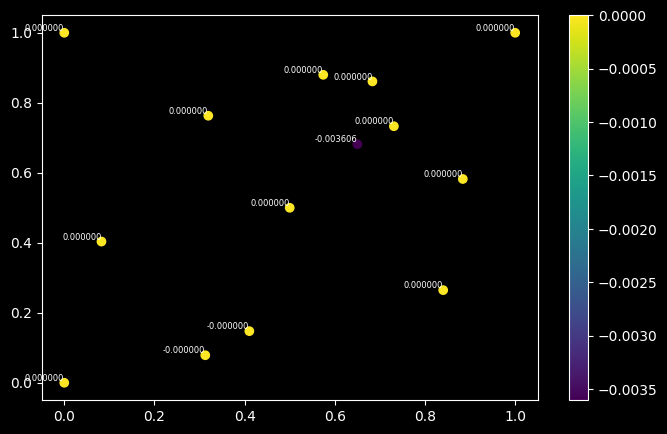

In [7]:
x = []
y = []
for i in input:
  x.append(i[0])
  y.append(i[1])

print(x)
print(y)
print(output)

fig, ax = plt.subplots()
fig.set_figheight(5)
fig.set_figwidth(8)

# Scatter plot
scatter = ax.scatter(x,y, c=output)

# Adding a color bar
plt.colorbar(scatter)

# Looping over the data points to add labels with 16 digits of precision
for i in range(len(x)):
#    x_coord = f"{X[i, 0]:.6f}"
#    y_coord = f"{X[i, 1]:.6f}"
    y_value = f"{output[i]:.6f}"
    label = f"{y_value}"
    ax.text(x[i], y[i], label, fontsize=6, ha='right', va='bottom')

plt.show()

# Bayesian Optimisation approach
We approach the study of this function with the Bayesian Optimisation
using and adaptation of the UCB acquisition function from required assignment 12.1

# Preparation of the exploration space
Here we prepare the exploration space of the function<br>
The values are increments of 0.01 bounded between 0 and 1 (included) => 101 values for each dimension of the space<br>
dimension of the current function is stored in <b>func_dimensions</b>

In [8]:
#Initialise query lists and maximum observations
X, Y = input, output

#Initialise grid for plots
vector_values = np.linspace(0, 1, 101)# 101 values from 0 to 1

# Generalised version for any number of dimension
grids = np.meshgrid(*([vector_values] * func_dimensions), indexing='ij')
x_grid = np.column_stack([grid.ravel() for grid in grids])

print(x_grid)
print(x_grid.shape)


[[0.   0.  ]
 [0.   0.01]
 [0.   0.02]
 ...
 [1.   0.98]
 [1.   0.99]
 [1.   1.  ]]
(10201, 2)


# Bayesian Optimisation with UCB applied

In [9]:
rbf_lengthscale = [0.1, 0.1]
real_noise_std = 1e-10
noise_assumption = 1e-10

#Define kernel of GP
kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds='fixed')

model = GaussianProcessRegressor(kernel = kernel)
#Fit the model
model.fit(np.array(X), np.array(Y).reshape(-1, 1))


#Calculate the mean and standard deviation and make them one-dimensional for plotting
post_mean, post_std = model.predict(x_grid, return_std=True)

#Acquisition function parameter
beta = 1.96
#beta = 0.0205

acquisition_function = post_mean + beta * post_std

grid = x_grid.squeeze()
obs = grid[np.argmax(acquisition_function)] #Else use the acquisition function

print('Next observation: ', obs)
#print (obs)


Next observation:  [1. 0.]


# Plottings

In [18]:
print(x_grid[0:10])
print(len(x_grid))
print(len(post_mean))

[[0.   0.  ]
 [0.   0.01]
 [0.   0.02]
 [0.   0.03]
 [0.   0.04]
 [0.   0.05]
 [0.   0.06]
 [0.   0.07]
 [0.   0.08]
 [0.   0.09]]
10201
10201


In [11]:
x_grid_reshaped = x_grid.reshape(101, -1, 2)
post_mean_reshaped = post_mean.reshape(101, -1, 1)
print(x_grid_reshaped[0:10])
print(post_mean_reshaped[0:10])



[[[0.   0.  ]
  [0.   0.01]
  [0.   0.02]
  ...
  [0.   0.98]
  [0.   0.99]
  [0.   1.  ]]

 [[0.01 0.  ]
  [0.01 0.01]
  [0.01 0.02]
  ...
  [0.01 0.98]
  [0.01 0.99]
  [0.01 1.  ]]

 [[0.02 0.  ]
  [0.02 0.01]
  [0.02 0.02]
  ...
  [0.02 0.98]
  [0.02 0.99]
  [0.02 1.  ]]

 ...

 [[0.07 0.  ]
  [0.07 0.01]
  [0.07 0.02]
  ...
  [0.07 0.98]
  [0.07 0.99]
  [0.07 1.  ]]

 [[0.08 0.  ]
  [0.08 0.01]
  [0.08 0.02]
  ...
  [0.08 0.98]
  [0.08 0.99]
  [0.08 1.  ]]

 [[0.09 0.  ]
  [0.09 0.01]
  [0.09 0.02]
  ...
  [0.09 0.98]
  [0.09 0.99]
  [0.09 1.  ]]]
[[[1.62793558e-19]
  [1.25786061e-10]
  [2.55816588e-10]
  ...
  [5.97650215e-10]
  [2.67737984e-10]
  [1.01809390e-19]]

 [[5.90213113e-10]
  [7.58415531e-10]
  [9.26960198e-10]
  ...
  [1.20353893e-09]
  [7.56250756e-10]
  [3.90381605e-10]]

 [[1.37317008e-09]
  [1.59642191e-09]
  [1.81479113e-09]
  ...
  [2.01988026e-09]
  [1.41701109e-09]
  [9.20876979e-10]]

 ...

 [[9.81656995e-09]
  [1.06166489e-08]
  [1.13534325e-08]
  ...
  [1.19

interactive(children=(FloatSlider(value=0.01, description='x', max=0.03, min=-0.01), Output()), _dom_classes=(…

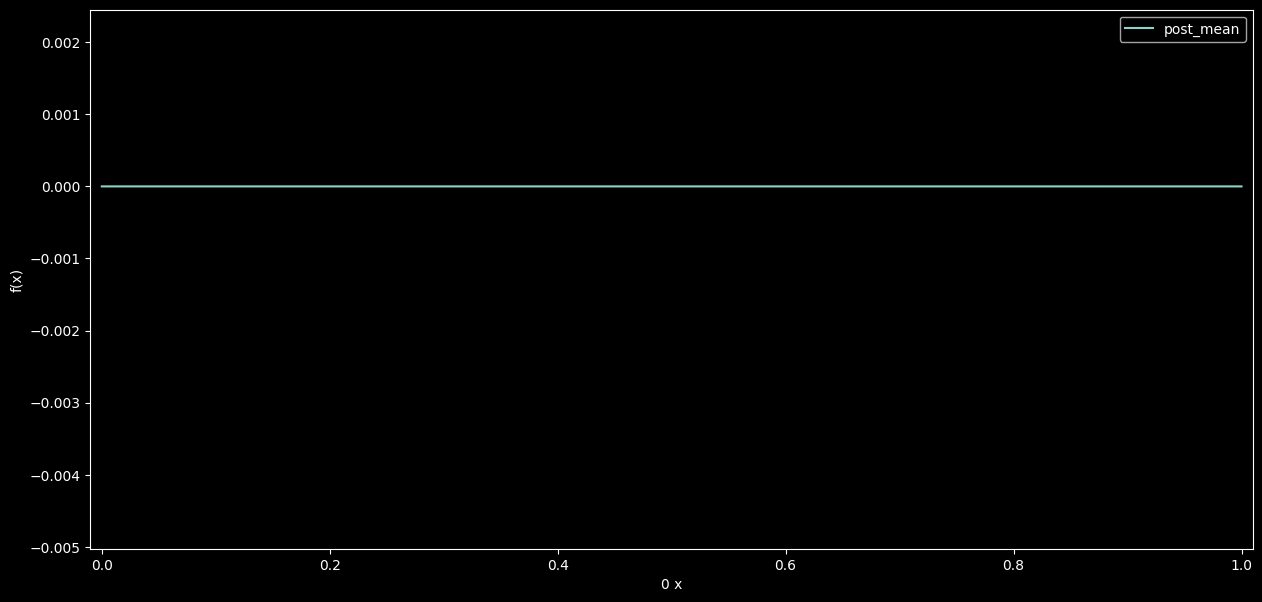

In [107]:
max_obs = 0
max_obs = max(max_obs, max(acquisition_function))

#Initialise plots
fig, ax = plt.subplots(figsize = (15, 7))

#Set the x and y limits, labels and dynamic title
ax.set_xlim(-0.01, 1.01)
ax.set_ylim(min(post_mean) - 0.001, max(post_mean) + 0.001)

#axamp = fig.add_axes([0.1, 0, 0.65, 0.03])
#axamp = fig.add_axes([0.25, 0.1, 0.65, 0.03])
#axfreq = fig.add_axes([0.25, 0.1, 0.65, 0.03])
#samp = Slider(axamp, label='X', valmin=0, valmax=1, valinit=0.00, valstep=0.01)

#def f(x):
#    return x


def update(x):
    print(x)
    val = int(x * 100)
    start = val*101
    end = start + 101
    l.set_xdata(x_grid[start:end])  # Add this line
    l.set_ydata(post_mean[start:end])
    ax.set_xlabel(str(val) + ' x')
    fig.canvas.draw_idle()
    ax.relim()
    ax.autoscale_view()
    fig.canvas.draw()
    return x

interact(update, x=0.01)

x = 0
val = int(x * 100)
start = val*101
end = start + 101
ax.set_ylabel('f(x)')
ax.set_xlabel(str(val) + ' x')
l, = ax.plot(vector_values, post_mean[start:end],  label = 'post_mean')
ax.legend()
plt.show()
#samp.on_changed(update)
#print(post_mean[start:end])
#ax.legend()

#for x in vector_values:
#    val = int(x * 100)
#    start = val*101
#    end = start + 101
#    ax.set_ylabel('f(x)')
#    ax.set_xlabel(str(val) + ' x')
#    ax.plot(x_grid[start:end], post_mean[start:end],  label = 'post_mean')
#    ax.legend()

#ax.plot(vector_values, post_mean[202:303],  label = 'post_mean')
#ax.plot(x_grid_reshaped[0], post_mean_reshaped[0],  label = 'post_mean')
#ax.plot(x_grid, post_std,  label = 'post_std')
#ax.plot(x_grid.squeeze(), post_mean, label = 'GP Posterior Mean')
#ax.fill_between(x_grid.squeeze(), post_mean - beta*post_std, post_mean + beta*post_std, alpha = 0.2, label = str(beta) + ' Standard Deviations')
#ax.legend()
#plt.show()



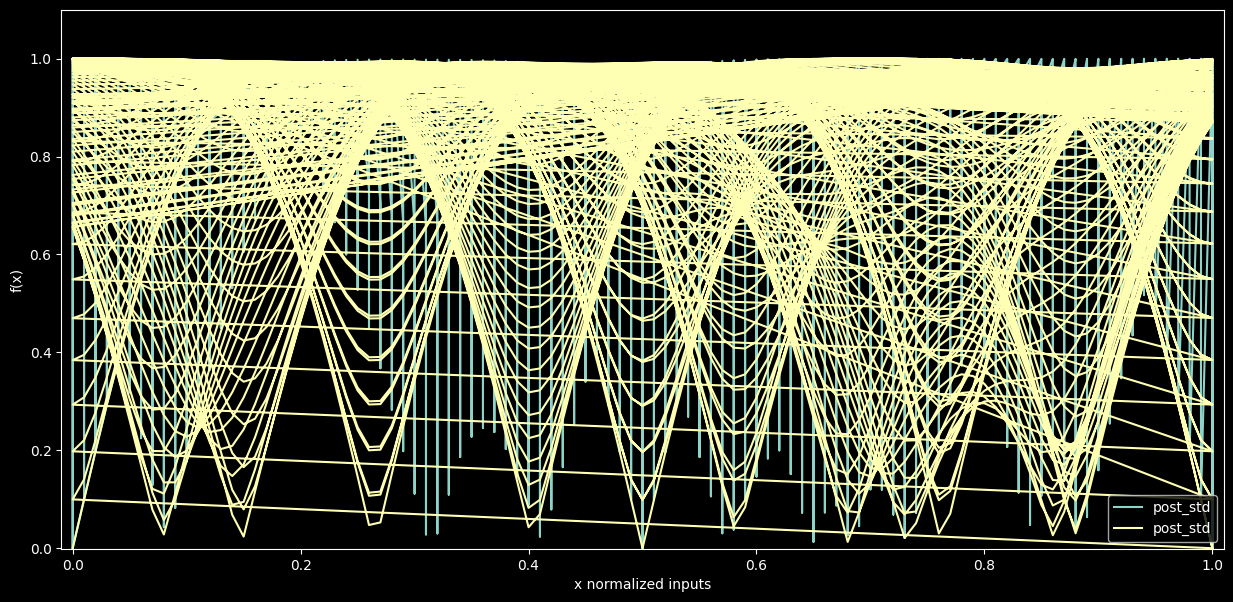

In [13]:
max_obs = 0
max_obs = max(max_obs, max(acquisition_function))

#Initialise plots
fig, ax = plt.subplots(figsize = (15, 7))
#Set the x and y limits, labels and dynamic title
ax.set_xlim(-0.01, 1.01)
ax.set_ylim(min(post_std) - 0.001, max(post_std) + 0.1)
ax.set_ylabel('f(x)')
ax.set_xlabel('x normalized inputs')
#Plot queries
#ax.scatter(X, Y, c = 'r', marker='x', s = 100)
#ax.scatter(x_grid.squeeze(), post_mean, c = 'r', marker='.', s = 100)

#Plot the mean and standard deviation
#ax.plot(x_grid, post_mean,  label = 'post_mean')
ax.plot(x_grid, post_std,  label = 'post_std')
#ax.plot(x_grid.squeeze(), post_mean, label = 'GP Posterior Mean')
#ax.fill_between(x_grid.squeeze(), post_mean - beta*post_std, post_mean + beta*post_std, alpha = 0.2, label = str(beta) + ' Standard Deviations')
ax.legend()
#plt.show()



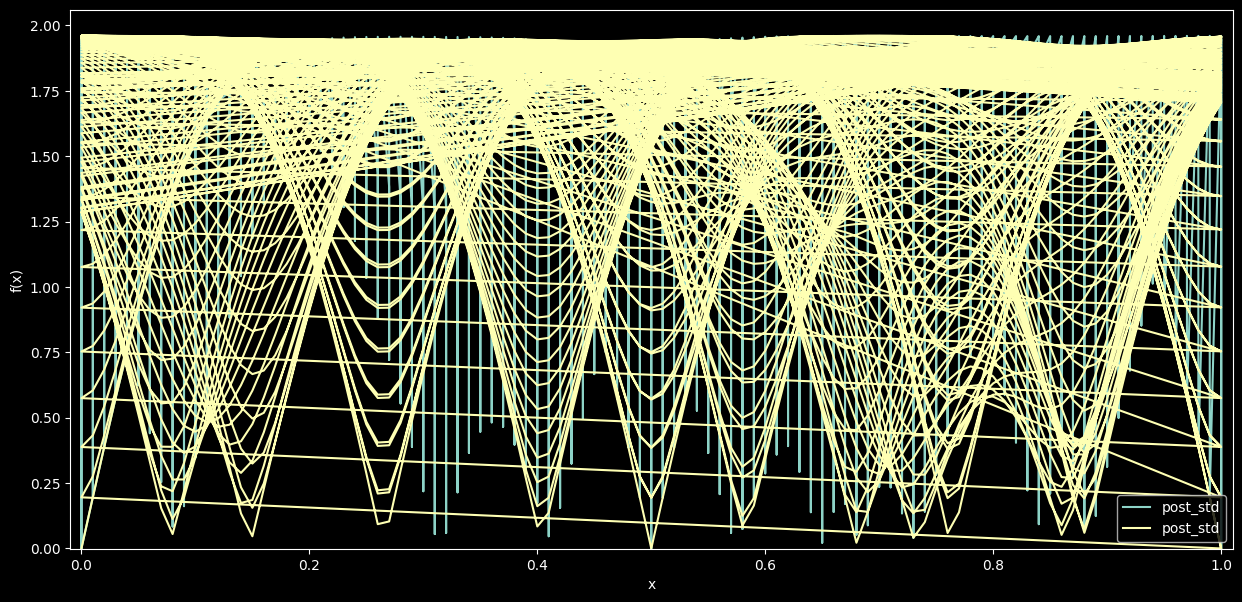

In [14]:
max_obs = 0
max_obs = max(max_obs, max(acquisition_function))

#Initialise plots
fig, ax = plt.subplots(figsize = (15, 7))
#Set the x and y limits, labels and dynamic title
ax.set_xlim(-0.01, 1.01)
ax.set_ylim(min(acquisition_function) - 0.001, max(acquisition_function) + 0.1)
ax.set_ylabel('f(x)')
ax.set_xlabel('x')
#Plot queries
#ax.scatter(X, Y, c = 'r', marker='x', s = 100)
#ax.scatter(x_grid.squeeze(), post_mean, c = 'r', marker='.', s = 100)

#Plot the mean and standard deviation
#ax.plot(x_grid, post_mean,  label = 'post_mean')
ax.plot(x_grid, acquisition_function,  label = 'post_std')
#ax.plot(x_grid.squeeze(), post_mean, label = 'GP Posterior Mean')
#ax.fill_between(x_grid.squeeze(), post_mean - beta*post_std, post_mean + beta*post_std, alpha = 0.2, label = str(beta) + ' Standard Deviations')
ax.legend()
#plt.show()

